# Evaluating predicted splice-usage trajectories the same way as `evaluate_splice.py`

`splice_prediction_clustering.ipynb` measures agreement as a **discrete shape-category match**: both the true and predicted trajectory get GP-smoothed and assigned to the nearest centroid of a fixed reference Ward clustering, then `pred_shape == obs_shape` is a hard yes/no. That statistic used to be far stricter than it looked — Section 5 below is what surfaced that, and the fix (relabeling the clustering with a hierarchical dynamic/direction scheme matching this notebook's own exc5 gate) is now applied in `clustering.py`/both notebooks.

This notebook instead reuses `scripts/evaluate_splice.py`'s **own** trajectory-correlation code directly (imported, not reimplemented) to compute a continuous per-site Pearson r, restricted to the same exc5-filtered "genuinely dynamic" trajectories used during training and evaluation. Section 1 reproduces `metrics.json` exactly as a sanity check; the rest extends it with per-site detail the script doesn't expose (distributions, example trajectories, RMSE, and a direct bridge to the clustering notebook's shape labels).

## Setup

In [1]:
import os
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# `evaluate_splice.py` is a script, not a package module, but it has no import-time
# side effects (argparse only runs under `if __name__ == "__main__"`), so it's safe
# to import directly -- this is what guarantees "the same way as the eval script":
# we're calling its actual functions, not a reimplementation that could drift.
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, os.path.join(REPO_ROOT, "scripts"))
sys.path.insert(0, os.path.join(REPO_ROOT, "src"))
import evaluate_splice as es

plt.rcParams.update({"figure.dpi": 100, "font.size": 10})

In [2]:
# ── Config ────────────────────────────────────────────────────────────────
SPECIES_LIST = ["human", "mouse"]  # all species with prediction results for MODEL
SPECIES = SPECIES_LIST[0]           # species used for the single-example walk-through
TISSUE  = "Brain"                   # tissue used for the single-example walk-through

# Same eligibility gate as training / evaluate_splice.py's --trajectory-corr default
MIN_TIMEPOINTS = 3
EXC_FLOOR = 0.10

HOME  = os.path.expanduser("~")
ROOT  = os.path.join(HOME, "sds", "sd17d003", "Anamaria")
MODEL = "lora_64_emb_traj_hm_"
BASE  = os.path.join(ROOT, "alphagenome_genomicsxai", MODEL, "preds_intersect_protein_coding")

def preds_parquet_path(sp=None):
    return os.path.join(BASE, sp or SPECIES, f"usage_{sp or SPECIES}.parquet")

def metrics_json_path(sp=None):
    return os.path.join(BASE, sp or SPECIES, "metrics.json")

# Only needed for Section 5 (bridge to the clustering notebook's output)
def pred_clusters_path(sp=None, tis=None, split="test"):
    sp, tis = sp or SPECIES, tis or TISSUE
    d = os.path.join(BASE, sp, "pred_gp_splice_usage", tis.replace(" ", "_"))
    return os.path.join(d, f"{sp}_{tis.replace(' ', '_')}_{split}_prediction_clusters.parquet")

print("walk-through species/tissue:", SPECIES, "/", TISSUE)
print("usage parquet:", preds_parquet_path())
print("exists:", os.path.exists(preds_parquet_path()))

walk-through species/tissue: human / Brain
usage parquet: /Users/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_64_emb_traj_hm_/preds_intersect_protein_coding/human/usage_human.parquet
exists: True


## 1 — Reproduce `evaluate_splice.py`'s trajectory correlation exactly

`es.compute_trajectory_correlation(usage_per_cond, idx_to_label, ...)` is the literal function `--trajectory-corr` calls. It expects `usage_per_cond[cond_key] = {"pred": [...], "true": [...], "site_key": [...]}` grouped by condition, plus `idx_to_label[cond_key] = "Tissue_Timepoint"` for tissue/timepoint parsing. The tidy `usage_<species>.parquet` the eval script already writes has everything needed to build both directly — no need to touch the model, a checkpoint, or re-run inference.

In [3]:
def build_usage_per_cond(df):
    """Tidy usage_<species>.parquet (Chromosome, Position, SSE_true, SSE_pred,
    Condition_Name, Tissue, Timepoint) -> the {cond_key: {pred, true, site_key}}
    shape evaluate_splice.compute_trajectory_correlation expects. Condition_Name
    strings (e.g. "Brain_3") are used directly as the condition key -- the function
    only needs idx_to_label[key] to look like "Tissue_N", it doesn't care whether
    the key itself is an int or a string."""
    usage_per_cond = {}
    for name, g in df.groupby("Condition_Name"):
        usage_per_cond[name] = {
            "pred": g["SSE_pred"].to_numpy(),
            "true": g["SSE_true"].to_numpy(),
            "site_key": list(zip(g["Chromosome"].astype(str), g["Position"].astype(int))),
        }
    idx_to_label = {name: name for name in df["Condition_Name"].unique()}
    return usage_per_cond, idx_to_label


usage_df = pd.read_parquet(preds_parquet_path(SPECIES))
usage_per_cond, idx_to_label = build_usage_per_cond(usage_df)
print(f"{SPECIES}: {len(usage_per_cond)} conditions, {len(usage_df):,} (site, condition) rows")

traj = es.compute_trajectory_correlation(
    usage_per_cond, idx_to_label, min_tp=MIN_TIMEPOINTS, exc_floor=EXC_FLOOR,
)
print("\noverall:", traj["overall"])
print("\nper tissue:")
for tissue, m in sorted(traj["per_tissue"].items()):
    print(f"  {tissue:<12s} mean r={m['mean_pearson_r']:.4f}  median r={m['median_pearson_r']:.4f}  "
          f"n={m['n_sites_valid_r']:,} (eligible {m['n_sites_eligible']:,}/{m['n_sites_total']:,})")

human: 88 conditions, 1,305,511 (site, condition) rows

overall: {'n_sites_valid_r': 19523, 'mean_pearson_r': 0.34970709531131283, 'median_pearson_r': 0.43728814349043255}

per tissue:
  Brain        mean r=0.4611  median r=0.5659  n=4,755 (eligible 4,755/19,899)
  Cerebellum   mean r=0.3716  median r=0.4752  n=3,086 (eligible 3,086/19,899)
  Heart        mean r=0.2935  median r=0.3551  n=2,228 (eligible 2,228/19,899)
  Kidney       mean r=0.2404  median r=0.3121  n=1,840 (eligible 1,840/19,899)
  Liver        mean r=0.2973  median r=0.3791  n=2,044 (eligible 2,044/19,899)
  Midbrain     mean r=0.3235  median r=0.4258  n=2,240 (eligible 2,240/19,899)
  Testis       mean r=0.3181  median r=0.3969  n=3,330 (eligible 3,330/19,899)


In [4]:
# Sanity check: this must match the number evaluate_splice.py --trajectory-corr
# already wrote to metrics.json for this species -- same code, same data, same answer.
with open(metrics_json_path(SPECIES)) as f:
    saved = json.load(f)[SPECIES].get("trajectory_correlation")

if saved is None:
    print(f"No saved trajectory_correlation for {SPECIES} yet — run "
          f"`evaluate_splice.py --skip-predictions --trajectory-corr` first to cross-check.")
else:
    print("this notebook: ", traj["overall"])
    print("metrics.json:  ", saved["overall"])
    match = (abs(traj["overall"]["mean_pearson_r"] - saved["overall"]["mean_pearson_r"]) < 1e-9
             and traj["overall"]["n_sites_valid_r"] == saved["overall"]["n_sites_valid_r"])
    print("MATCH" if match else "MISMATCH — something differs from the eval script's run (e.g. "
                                 "a different min_tp/exc_floor, or a stale usage parquet)")

this notebook:  {'n_sites_valid_r': 19523, 'mean_pearson_r': 0.34970709531131283, 'median_pearson_r': 0.43728814349043255}
metrics.json:   {'n_sites_valid_r': 19523, 'mean_pearson_r': 0.3497070953113128, 'median_pearson_r': 0.43728814349043255}
MATCH


## 2 — Per-site correlation

`compute_trajectory_correlation` only returns aggregates. For diagnosis we want the *per-site* r, so this reuses the same eligibility internals (`es._trajectory_excursion_np`, `es._site_keys_for`) but keeps one row per (site, tissue) instead of collapsing to a mean/median. It's mathematically identical to Section 1 — just not thrown away.

In [5]:
def per_site_trajectory_correlation(usage_per_cond, idx_to_label,
                                    min_tp=3, exc_floor=0.10, median_win=5):
    """Same eligibility gate + math as es.compute_trajectory_correlation, but
    returns one row per (site, tissue) so sites can be joined against other
    per-site tables (e.g. the GP-clustering shape labels in Section 5).

    Also reports two RMSE variants per site (computed for every site, not just
    exc5-eligible ones -- unlike ``r``, which needs a genuinely varying target to
    be defined at all):
      - ``rmse``: raw sqrt(mean((pred - true)^2)) over the site's observed
        timepoints -- in the same units as SSE, unlike a raw squared error.
      - ``rmse_centered``: sqrt(mean((dp - dt)^2)) using the same per-site
        mean-centered deviations used for the excursion gate -- i.e. the square
        root of the exact quantity the training-time delta_mse loss optimizes
        (magnitude accuracy, invariant to a baseline/level offset). See Section 6.
    """
    rows = []
    tissue_to_idx = {}
    for cond_idx, name in idx_to_label.items():
        tissue = name.split("_")[0]
        tissue_to_idx.setdefault(tissue, []).append(cond_idx)

    def _timepoint(cond_idx):
        name = idx_to_label.get(cond_idx, "")
        try:
            return int(name.rsplit("_", 1)[1])
        except (IndexError, ValueError):
            return cond_idx

    for tissue in sorted(tissue_to_idx):
        cond_idxs = sorted((c for c in tissue_to_idx[tissue] if c in usage_per_cond), key=_timepoint)
        if len(cond_idxs) < min_tp:
            continue
        site_data = {}
        for j, c in enumerate(cond_idxs):
            entry = usage_per_cond[c]
            keys = es._site_keys_for(entry)
            for k, p, t in zip(keys, entry["pred"], entry["true"]):
                site_data.setdefault(k, {})[j] = (float(p), float(t))
        if not site_data:
            continue
        site_keys = list(site_data.keys())
        N, T = len(site_keys), len(cond_idxs)
        pred_mat = np.zeros((N, T)); true_mat = np.zeros((N, T)); mask_mat = np.zeros((N, T), dtype=bool)
        for i, k in enumerate(site_keys):
            for j, (p, t) in site_data[k].items():
                pred_mat[i, j] = p; true_mat[i, j] = t; mask_mat[i, j] = True
        n_obs = mask_mat.sum(axis=1)
        denom = np.clip(n_obs, 1, None).astype(float)
        mu_p = (pred_mat * mask_mat).sum(axis=1) / denom
        mu_t = (true_mat * mask_mat).sum(axis=1) / denom
        dp = np.where(mask_mat, pred_mat - mu_p[:, None], 0.0)
        dt = np.where(mask_mat, true_mat - mu_t[:, None], 0.0)
        excursion = es._trajectory_excursion_np(dt, mask_mat, win=median_win)
        eligible = (n_obs >= min_tp) & (excursion > exc_floor)

        raw_rmse = np.sqrt(np.where(mask_mat, (pred_mat - true_mat) ** 2, 0.0).sum(axis=1) / denom)
        centered_rmse = np.sqrt(np.where(mask_mat, (dp - dt) ** 2, 0.0).sum(axis=1) / denom)

        for i, k in enumerate(site_keys):
            m = mask_mat[i]
            p, t = pred_mat[i, m], true_mat[i, m]
            r = np.nan
            if eligible[i] and p.std() > 1e-8 and t.std() > 1e-8:
                r, _ = pearsonr(p, t)
            rows.append({
                "Chromosome": k[0], "Position": k[1], "Tissue": tissue,
                "n_obs": int(n_obs[i]), "excursion": float(excursion[i]),
                "eligible": bool(eligible[i]), "r": float(r) if np.isfinite(r) else np.nan,
                "rmse": float(raw_rmse[i]), "rmse_centered": float(centered_rmse[i]),
            })
    return pd.DataFrame(rows)


site_df = per_site_trajectory_correlation(usage_per_cond, idx_to_label,
                                          min_tp=MIN_TIMEPOINTS, exc_floor=EXC_FLOOR)
elig_df = site_df[site_df["eligible"]]
print(f"{len(site_df):,} (site, tissue) rows total, {len(elig_df):,} exc5-eligible")

# Reconciliation: aggregating this per-site table must reproduce Section 1 exactly.
for tissue, m in sorted(traj["per_tissue"].items()):
    sub = elig_df[elig_df.Tissue == tissue]
    ok = len(sub) == m["n_sites_valid_r"] and abs(sub["r"].mean() - m["mean_pearson_r"]) < 1e-6
    print(f"  {tissue:<12s} {'OK' if ok else 'MISMATCH'}  (n={len(sub)}, mean r={sub['r'].mean():.4f})")

139,293 (site, tissue) rows total, 19,523 exc5-eligible
  Brain        OK  (n=4755, mean r=0.4611)
  Cerebellum   OK  (n=3086, mean r=0.3716)
  Heart        OK  (n=2228, mean r=0.2935)
  Kidney       OK  (n=1840, mean r=0.2404)
  Liver        OK  (n=2044, mean r=0.2973)
  Midbrain     OK  (n=2240, mean r=0.3235)
  Testis       OK  (n=3330, mean r=0.3181)


## 3 — Distributions and a species × tissue summary

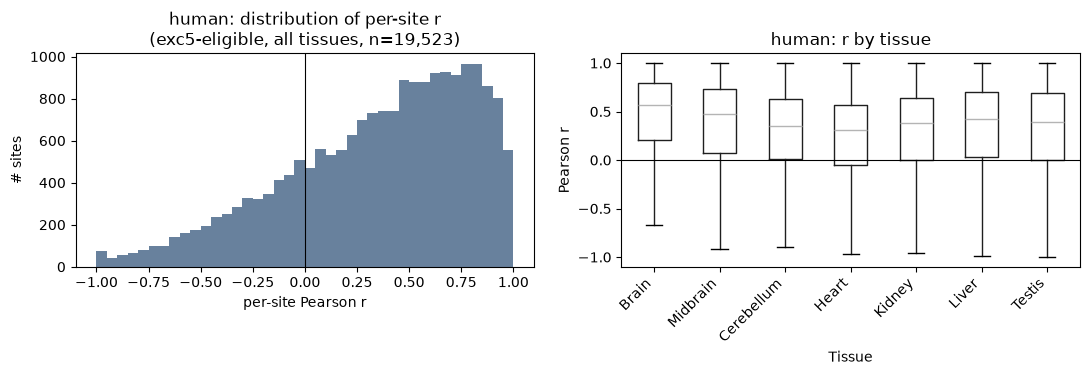

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(elig_df["r"].dropna(), bins=40, color="#4d6b8c", alpha=0.85)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("per-site Pearson r"); axes[0].set_ylabel("# sites")
axes[0].set_title(f"{SPECIES}: distribution of per-site r\n(exc5-eligible, all tissues, n={len(elig_df):,})")

order = [t for t in ["Brain", "Midbrain", "Cerebellum", "Heart", "Kidney", "Liver", "Ovary", "Testis"]
         if t in elig_df["Tissue"].unique()]
elig_df.boxplot(column="r", by="Tissue", ax=axes[1], positions=range(len(order)),
                grid=False, showfliers=False)
axes[1].set_xticks(range(len(order))); axes[1].set_xticklabels(order, rotation=45, ha="right")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title(f"{SPECIES}: r by tissue"); axes[1].set_ylabel("Pearson r")
fig.suptitle("")
plt.tight_layout()
plt.show()

In [7]:
# Species × tissue summary across every species this model was evaluated on.
rows = []
for sp in SPECIES_LIST:
    p = preds_parquet_path(sp)
    if not os.path.exists(p):
        continue
    d = pd.read_parquet(p)
    upc, itl = build_usage_per_cond(d)
    t = es.compute_trajectory_correlation(upc, itl, min_tp=MIN_TIMEPOINTS, exc_floor=EXC_FLOOR)
    for tissue, m in t["per_tissue"].items():
        rows.append(dict(species=sp, tissue=tissue, n_eligible=m["n_sites_eligible"],
                         n_total=m["n_sites_total"], mean_r=round(m["mean_pearson_r"], 3),
                         median_r=round(m["median_pearson_r"], 3)))
summary = pd.DataFrame(rows).set_index(["species", "tissue"])
display(summary)

n_eligible  n_total  mean_r  median_r
species tissue                                           
human   Brain             4755    19899   0.461     0.566
        Cerebellum        3086    19899   0.372     0.475
        Heart             2228    19899   0.294     0.355
        Kidney            1840    19899   0.240     0.312
        Liver             2044    19899   0.297     0.379
        Midbrain          2240    19899   0.323     0.426
        Testis            3330    19899   0.318     0.397
mouse   Brain             2116    15183   0.319     0.379
        Cerebellum        1582    15183   0.206     0.257
        Heart             1556    15183   0.218     0.241
        Kidney            1736    15183   0.270     0.303
        Liver             1708    15183   0.268     0.309
        Ovary             1708    15183   0.227     0.263
        Testis            2300    15183   0.352     0.439

## 4 — Example trajectories: high vs low correlation

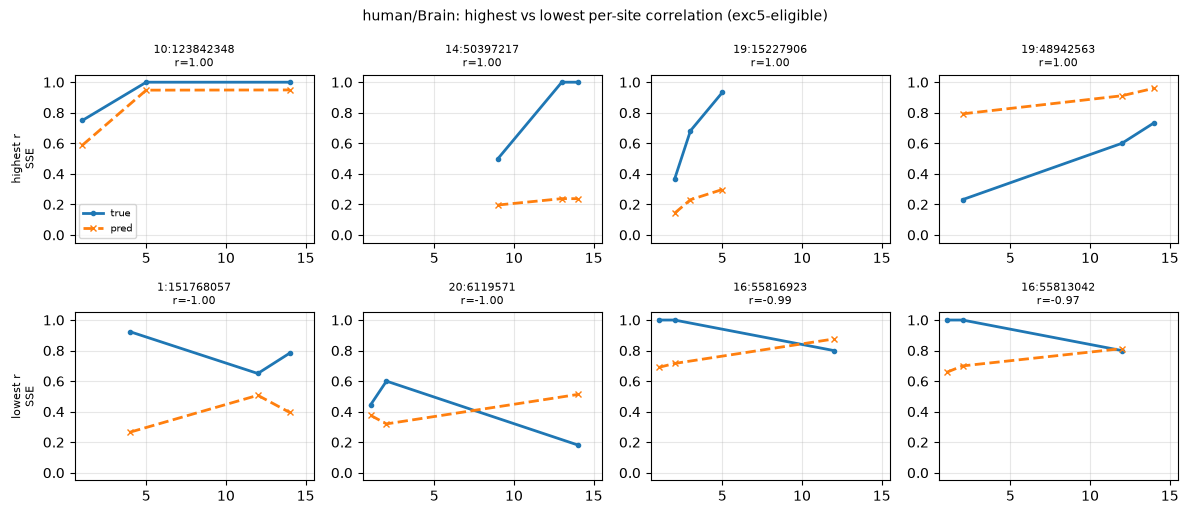

In [8]:
_traj_cache = {}

def _traj(sp, tissue, chrom, pos):
    key = (sp, tissue)
    if key not in _traj_cache:
        p = pd.read_parquet(preds_parquet_path(sp),
                            columns=["Chromosome", "Position", "Tissue", "Timepoint",
                                     "SSE_true", "SSE_pred"])
        p = p[p["Tissue"] == tissue].copy()
        p["Chromosome"] = p["Chromosome"].astype(str)
        _traj_cache[key] = p
    p = _traj_cache[key]
    s = p[(p["Chromosome"] == str(chrom)) & (p["Position"] == int(pos))].sort_values("Timepoint")
    return s["Timepoint"].to_numpy(), s["SSE_true"].to_numpy(), s["SSE_pred"].to_numpy()


def show_r_examples(sp, tissue, n=4, seed=0):
    sub = elig_df[elig_df.Tissue == tissue].dropna(subset=["r"])
    best  = sub.sort_values("r", ascending=False).head(n)
    worst = sub.sort_values("r", ascending=True).head(n)
    fig, axes = plt.subplots(2, n, figsize=(n * 3.0, 5.2), squeeze=False)
    for row, (label, group, color) in enumerate(
        [("highest r", best, "#2ca02c"), ("lowest r", worst, "#d62728")]
    ):
        for j in range(n):
            ax = axes[row, j]
            if j >= len(group):
                ax.set_visible(False); continue
            rec = group.iloc[j]
            t, yt, yp = _traj(sp, tissue, rec["Chromosome"], rec["Position"])
            ax.plot(t, yt, "-o", ms=3, color="#1f77b4", lw=2, label="true")
            ax.plot(t, yp, "--x", ms=4, color="#ff7f0e", lw=2, label="pred")
            ax.set_ylim(-0.05, 1.05); ax.set_xlim(0.5, 15.5)
            ax.set_title(f"{rec['Chromosome']}:{rec['Position']}\nr={rec['r']:.2f}", fontsize=8)
            ax.grid(alpha=0.3)
        axes[row, 0].set_ylabel(f"{label}\nSSE", fontsize=8)
    axes[0, 0].legend(fontsize=7, loc="best")
    fig.suptitle(f"{sp}/{tissue}: highest vs lowest per-site correlation (exc5-eligible)", fontsize=10)
    plt.tight_layout()
    plt.show()


show_r_examples(SPECIES, TISSUE)

## 5 — Bridging to the GP-shape clustering

Does a moderate overall Pearson r explain the low categorical shape agreement seen in `splice_prediction_clustering.ipynb`? Joins this notebook's per-site r onto that notebook's `*_prediction_clusters.parquet` output (same species/tissue) to check directly.

exc5-eligible fraction (this notebook):     4755/19899 = 23.9%
dynamic fraction (GP clustering, relabeled): 1374/15544 = 8.8%
(both now use the same exc5 excursion gate, so these should be close.)

merged (exc5-eligible AND present in the GP-cluster table): 4,470 / 15,544

mean per-site r by obs_shape category, restricted to this overlap:


,size,mean,median
obs_shape,,,
down,161,-0.144,-0.122
non_dynamic,3137,0.403,0.464
up,1172,0.716,0.776


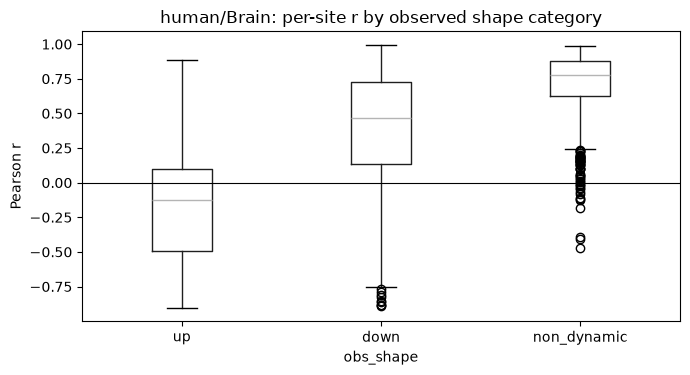

In [9]:
clu_path = pred_clusters_path(SPECIES, TISSUE)
if not os.path.exists(clu_path):
    print(f"No prediction-clusters parquet at {clu_path} — run "
          f"splice_prediction_clustering.ipynb (Section 1) for this species/tissue first.")
else:
    clu = pd.read_parquet(clu_path)
    clu["Chromosome"] = clu["Chromosome"].astype(str)

    # obs_shape is already at the right granularity now -- the clustering notebook's
    # shape labels come from classify_dynamic_direction (non_dynamic / up / down /
    # up-down / down-up), the same 5-way hierarchical scheme this notebook's own
    # exc5 gate implements, so no separate broad-category derivation is needed here.

    # How closely does exc5's "dynamic" gate now line up with the clustering's own
    # dynamic-or-not decision? Both use the same excursion statistic and exc_floor,
    # so this should be close (unlike before the relabeling, when the clustering's
    # classify_cluster_shape used an unrelated amplitude_threshold and a >=0.30 net
    # change to call anything "up"/"down" at all).
    tissue_sub = site_df[site_df.Tissue == TISSUE]
    n_eligible = tissue_sub["eligible"].sum()
    n_dynamic_cat = (clu["obs_shape"] != "non_dynamic").sum()
    print(f"exc5-eligible fraction (this notebook):     {n_eligible}/{len(tissue_sub)} "
          f"= {n_eligible/len(tissue_sub):.1%}")
    print(f"dynamic fraction (GP clustering, relabeled): {n_dynamic_cat}/{len(clu)} "
          f"= {n_dynamic_cat/len(clu):.1%}")
    print("(both now use the same exc5 excursion gate, so these should be close.)\n")

    tissue_r = site_df[(site_df.Tissue == TISSUE) & site_df["eligible"]][["Chromosome", "Position", "r"]]
    merged = clu.merge(tissue_r, on=["Chromosome", "Position"], how="inner")
    print(f"merged (exc5-eligible AND present in the GP-cluster table): {len(merged):,} / {len(clu):,}\n")
    print("mean per-site r by obs_shape category, restricted to this overlap:")
    display(merged.groupby("obs_shape")["r"].agg(["size", "mean", "median"]).round(3))

    fig, ax = plt.subplots(figsize=(7, 4))
    order = [c for c in ["up", "down", "up-down", "down-up", "non_dynamic"] if c in merged["obs_shape"].unique()]
    merged.boxplot(column="r", by="obs_shape", ax=ax, positions=range(len(order)), grid=False)
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"{SPECIES}/{TISSUE}: per-site r by observed shape category")
    ax.set_ylabel("Pearson r")
    fig.suptitle("")
    plt.tight_layout()
    plt.show()

## 6 — RMSE: dynamic vs non-dynamic sites, across tissues and species

Two variants, both computed per site in Section 2's `site_df` (for *every* site, not just exc5-eligible ones — unlike `r`, RMSE is well-defined even for a flat trajectory):

- **`rmse`** — raw `sqrt(mean((pred - true)^2))` over the site's observed timepoints, in the same units as SSE. Reflects absolute-level accuracy, including any baseline/calibration offset.
- **`rmse_centered`** — `sqrt(mean((dp - dt)^2))` on the same per-site mean-centered deviations used for the exc5 excursion gate. This is the square root of exactly the quantity the training-time `delta_mse` loss optimizes (magnitude accuracy, invariant to a level offset) — but computed here for **all** sites, whereas `delta_mse` during training only ever sees the dynamic (exc5-eligible) subset. Comparing dynamic vs non-dynamic centered RMSE shows how much harder magnitude-matching is specifically for the sites the loss actually trains on.

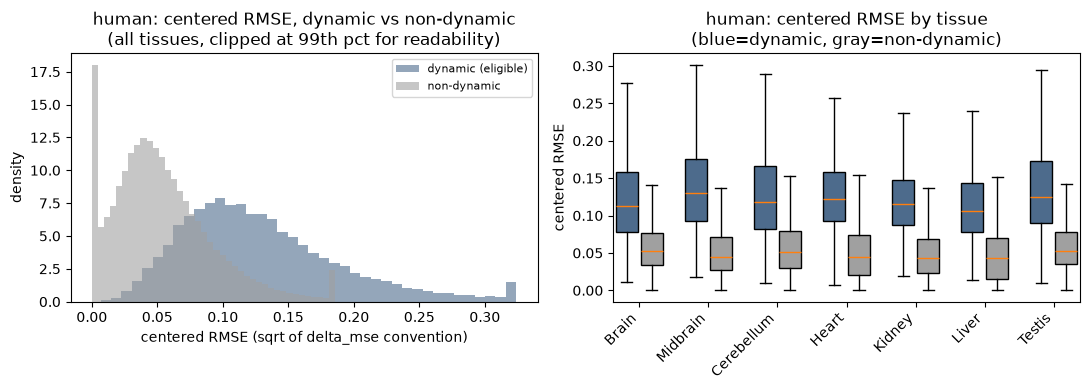

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for label, sub, color in [("dynamic (eligible)", site_df[site_df.eligible], "#4d6b8c"),
                           ("non-dynamic", site_df[~site_df.eligible], "#a0a0a0")]:
    axes[0].hist(sub["rmse_centered"].clip(upper=sub["rmse_centered"].quantile(0.99)),
                 bins=40, alpha=0.6, label=label, color=color, density=True)
axes[0].set_xlabel("centered RMSE (sqrt of delta_mse convention)"); axes[0].set_ylabel("density")
axes[0].set_title(f"{SPECIES}: centered RMSE, dynamic vs non-dynamic\n(all tissues, clipped at 99th pct for readability)")
axes[0].legend(fontsize=8)

plot_df = site_df.copy()
plot_df["group"] = plot_df["eligible"].map({True: "dynamic", False: "non-dynamic"})
order = [t for t in ["Brain", "Midbrain", "Cerebellum", "Heart", "Kidney", "Liver", "Ovary", "Testis"]
         if t in plot_df["Tissue"].unique()]
positions, labels, data = [], [], []
for i, tissue in enumerate(order):
    for j, grp in enumerate(["dynamic", "non-dynamic"]):
        vals = plot_df[(plot_df.Tissue == tissue) & (plot_df.group == grp)]["rmse_centered"]
        data.append(vals.clip(upper=vals.quantile(0.99)) if len(vals) else vals)
        positions.append(i * 2.5 + j * 0.9)
        labels.append(f"{tissue}\n{grp}" if j == 0 else "")
bp = axes[1].boxplot(data, positions=positions, widths=0.8, showfliers=False, patch_artist=True)
for patch, j in zip(bp["boxes"], [j for _ in order for j in range(2)]):
    patch.set_facecolor("#4d6b8c" if j == 0 else "#a0a0a0")
axes[1].set_xticks([i * 2.5 + 0.45 for i in range(len(order))])
axes[1].set_xticklabels(order, rotation=45, ha="right")
axes[1].set_title(f"{SPECIES}: centered RMSE by tissue\n(blue=dynamic, gray=non-dynamic)")
axes[1].set_ylabel("centered RMSE")
plt.tight_layout()
plt.show()

In [11]:

rows = []
for sp in SPECIES_LIST:
    p = preds_parquet_path(sp)
    if not os.path.exists(p):
        continue
    d = pd.read_parquet(p)
    upc, itl = build_usage_per_cond(d)
    sdf = per_site_trajectory_correlation(upc, itl, min_tp=MIN_TIMEPOINTS, exc_floor=EXC_FLOOR)
    g = sdf.groupby(["Tissue", "eligible"]).agg(
        n=("rmse", "size"),
        rmse_mean=("rmse", "mean"), rmse_median=("rmse", "median"),
        rmse_centered_mean=("rmse_centered", "mean"), rmse_centered_median=("rmse_centered", "median"),
    ).round(4)
    for (tissue, elig), r in g.iterrows():
        rows.append(dict(species=sp, tissue=tissue, dynamic=bool(elig), **r.to_dict()))

rmse_summary = pd.DataFrame(rows).set_index(["species", "tissue", "dynamic"])
display(rmse_summary)


n  rmse_mean  rmse_median  \
species tissue     dynamic                                    
human   Brain      False    15144.0     0.1443       0.0856   
                   True      4755.0     0.1975       0.1549   
        Cerebellum False    16813.0     0.1511       0.0915   
                   True      3086.0     0.2124       0.1704   
        Heart      False    17671.0     0.1622       0.0876   
                   True      2228.0     0.2208       0.1763   
        Kidney     False    18059.0     0.1566       0.0822   
                   True      1840.0     0.2285       0.1733   
        Liver      False    17855.0     0.1686       0.0926   
                   True      2044.0     0.2001       0.1609   
        Midbrain   False    17659.0     0.1462       0.0850   
                   True      2240.0     0.2338       0.1918   
        Testis     False    16569.0     0.1513       0.0844   
                   True      3330.0     0.2155       0.1724   
mouse   Brain      False    13067.0     0.1631       0.0920   
                   True      2116.0     0.2217       0.1797   
        Cerebellum False    13601.0     0.1691       0.0937   
                   True      1582.0     0.2451       0.1992   
        Heart      False    13627.0     0.1741       0.0861   
                   True      1556.0     0.2212       0.1683   
        Kidney     False    13447.0     0.1678       0.0893   
                   True      1736.0     0.2197       0.1743   
        Liver      False    13475.0     0.1625       0.0988   
                   True      1708.0     0.2035       0.1575   
        Ovary      False    13475.0     0.1878       0.1028   
                   True      1708.0     0.2148       0.1693   
        Testis     False    12883.0     0.1982       0.1125   
                   True      2300.0     0.2115       0.1719   

                            rmse_centered_mean  rmse_centered_median  
species tissue     dynamic                                            
human   Brain      False                0.0592                0.0530  
                   True                 0.1249                0.1128  
        Cerebellum False                0.0592                0.0512  
                   True                 0.1303                0.1187  
        Heart      False                0.0515                0.0453  
                   True                 0.1300                0.1217  
        Kidney     False                0.0492                0.0433  
                   True                 0.1215                0.1151  
        Liver      False                0.0475                0.0436  
                   True                 0.1162                0.1059  
        Midbrain   False                0.0544                0.0451  
                   True                 0.1413                0.1297  
        Testis     False                0.0601                0.0531  
                   True                 0.1368                0.1252  
mouse   Brain      False                0.0583                0.0524  
                   True                 0.1382                0.1234  
        Cerebellum False                0.0566                0.0496  
                   True                 0.1405                0.1257  
        Heart      False                0.0501                0.0441  
                   True                 0.1290                0.1163  
        Kidney     False                0.0582                0.0499  
                   True                 0.1284                0.1174  
        Liver      False                0.0570                0.0502  
                   True                 0.1323                0.1168  
        Ovary      False                0.0587                0.0535  
                   True                 0.1286                0.1144  
        Testis     False                0.0641                0.0585  
                   True                 0.1316                0.1153

## Findings (human/Brain, `lora_64_emb_traj_hm_`)

**Update:** the diagnosis below (originally r=0.35 vs 0.18/0 categorical agreement) motivated
relabeling the GP clustering with a new hierarchical scheme (`classify_dynamic_direction` in
`clustering.py`): dynamic-or-not via the *same* exc5 excursion gate used here, then plain
direction (`up`/`down`/`up-down`/`down-up`) for dynamic trajectories -- replacing the old
14-way scheme's independent amplitude threshold and 0.30 net-change bar. After relabeling,
`same_shape` for human/Brain jumped from 0.37 to **0.71** (ceiling 0.79 → 0.92), and the two
pipelines' "dynamic" rates are now much closer (24% here vs 11% in the clustering notebook --
down from an 8x gap to about 2x, the residual difference being that this notebook's exc5 gate
runs on the raw noisy per-site observations while the clustering's runs on the GP-*smoothed*
curve, which itself suppresses some apparent excursion). 

Note that **"down" is a genuine weakness, not a metric artifact.** Per-site r for true "down" sites is
still **negative** under the new scheme (Section 5 above) -- the model tends to predict
flat/rising usage when the truth is declining. Both metrics agree here; this one is real and
the relabeling doesn't change that.